Dataset pronto.
Treino: (1000, 128, 128, 3) (1000, 4)
Teste : (100, 128, 128, 3) (100, 4)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 64, 64, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 30, 30, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │     1,728,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,741,496 (6.64 MB)

 Trainable params: 1,741,496 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
32/32 - 16s - 491ms/step - loss: 0.0514 - mae: 0.1924 - val_loss: 0.0504 - val_mae: 0.1920
Epoch 2/40
32/32 - 14s - 430ms/step - loss: 0.0459 - mae: 0.1840 - val_loss: 0.0474 - val_mae: 0.1849
Epoch 3/40
32/32 - 14s - 443ms/step - loss: 0.0381 - mae: 0.1641 - val_loss: 0.0446 - val_mae: 0.1755
Epoch 4/40
32/32 - 14s - 428ms/step - loss: 0.0285 - mae: 0.1377 - val_loss: 0.0421 - val_mae: 0.1709
Epoch 5/40
32/32 - 20s - 640ms/step - loss: 0.0202 - mae: 0.1135 - val_loss: 0.0412 - val_mae: 0.1565
Epoch 6/40
32/32 - 15s - 458ms/step - loss: 0.0160 - mae: 0.0993 - val_loss: 0.0377 - val_mae: 0.1475
Epoch 7/40
32/32 - 14s - 424ms/step - loss: 0.0108 - mae: 0.0816 - val_loss: 0.0392 - val_mae: 0.1527
Epoch 8/40
32/32 - 14s - 432ms/step - loss: 0.0086 - mae: 0.0721 - val_loss: 0.0372 - val_mae: 0.1462
Epoch 9/40
32/32 - 14s - 424ms/step - loss: 0.0059 - mae: 0.0594 - val_loss: 0.0359 - val_mae: 0.1452
Epoch 10/40
32/32 - 14s - 429ms/step - loss: 0.0038 - mae: 0.0472 - val_loss: 0.03

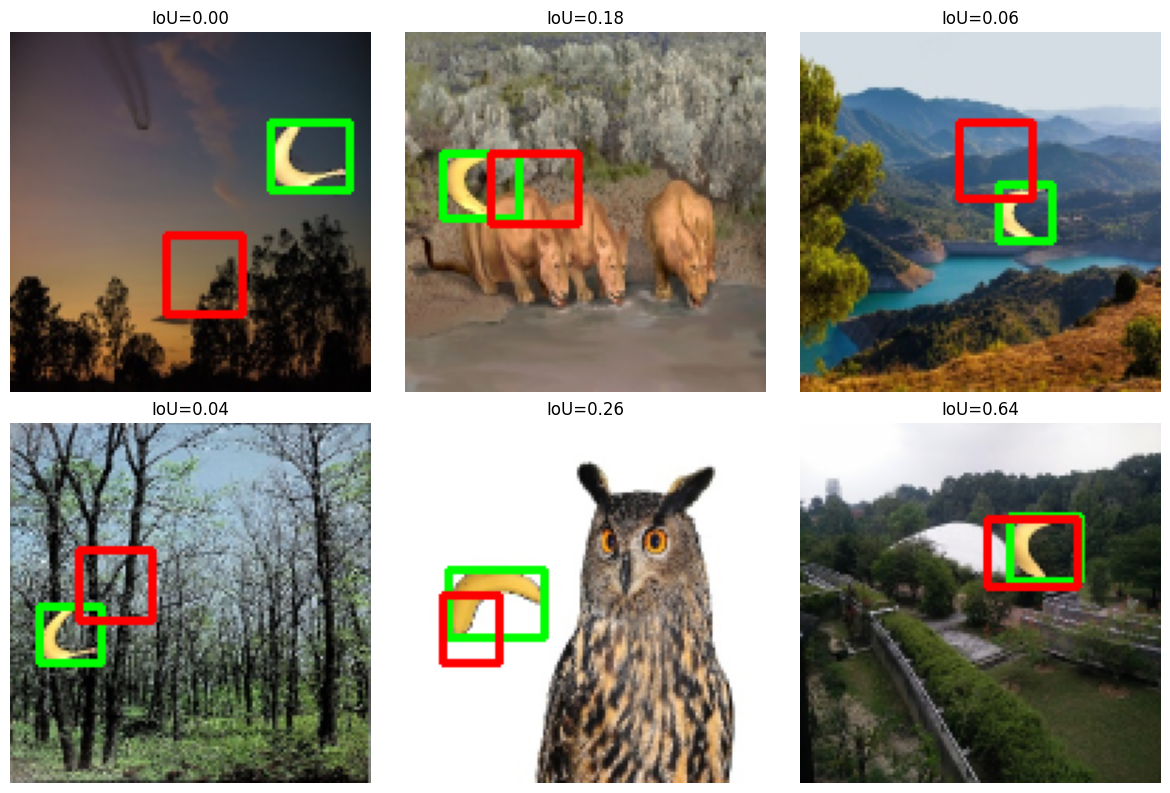

In [1]:
# banana_lenet_bbox.py
# Localização de banana com uma CNN tipo LeNet

import os
import zipfile
import subprocess
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# 1) Download do dataset
# ============================================================
def download_banana_dataset():
    nomeArq = "banana-detection.zip"

    if not os.path.exists(nomeArq):
        print("Baixando banana-detection.zip ...")
        try:
            import gdown
        except ImportError:
            subprocess.check_call(["pip", "install", "--upgrade", "gdown"])
            import gdown

        gdown.download(id="1J7IEFUlq8_ORnKGR3mthNjEQ5ecXmZY_", output=nomeArq, quiet=False)

    if not os.path.exists("banana-detection"):
        print("Descompactando dataset ...")
        with zipfile.ZipFile(nomeArq, "r") as zf:
            zf.extractall("banana-detection")

    print("Dataset pronto.")


# ============================================================
# 2) Localização das pastas
# ============================================================
def find_split_paths(root_dir, split):
    candidates = [
        os.path.join(root_dir, split),
        os.path.join(root_dir, "bananas_train" if split == "train" else "bananas_val"),
        os.path.join(root_dir, "banana-detection", split),
        os.path.join(root_dir, "banana-detection", "bananas_train" if split == "train" else "bananas_val"),
    ]

    for c in candidates:
        csv_path = os.path.join(c, "label.csv")
        img_dir = os.path.join(c, "images")
        if os.path.exists(csv_path) and os.path.isdir(img_dir):
            return csv_path, img_dir

    raise FileNotFoundError(f"Não encontrei o split '{split}' em {root_dir}")


# ============================================================
# 3) Leitura do dataset
# ============================================================
def load_banana_split(root_dir, split="train", img_size=128):
    csv_path, img_dir = find_split_paths(root_dir, split)

    df = pd.read_csv(csv_path)

    X = []
    y = []

    for _, row in df.iterrows():
        img_path = os.path.join(img_dir, row["img_name"])
        img = cv2.imread(img_path)

        if img is None:
            raise FileNotFoundError(f"Não foi possível abrir {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))

        X.append(img)

        # normaliza bbox para [0,1]
        bbox = np.array([
            row["xmin"] / 256.0,
            row["ymin"] / 256.0,
            row["xmax"] / 256.0,
            row["ymax"] / 256.0,
        ], dtype=np.float32)

        y.append(bbox)

    X = np.array(X, dtype=np.float32) / 255.0
    y = np.array(y, dtype=np.float32)

    return X, y, df


# ============================================================
# 4) Métrica IoU
# ============================================================
def compute_iou(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)

    union = area_a + area_b - inter_area
    if union <= 0:
        return 0.0

    return inter_area / union


def mean_iou(y_true, y_pred):
    vals = [compute_iou(a, b) for a, b in zip(y_true, y_pred)]
    return float(np.mean(vals))


# ============================================================
# 5) Modelo tipo LeNet
# ============================================================
def build_lenet_bbox(img_size=128):
    """
    LeNet adaptada para regressão de bounding box.
    """
    model = keras.Sequential([
        keras.Input(shape=(img_size, img_size, 3)),

        layers.Conv2D(6, kernel_size=5, activation="relu", padding="same"),
        layers.AveragePooling2D(pool_size=2),

        layers.Conv2D(16, kernel_size=5, activation="relu"),
        layers.AveragePooling2D(pool_size=2),

        layers.Flatten(),
        layers.Dense(120, activation="relu"),
        layers.Dense(84, activation="relu"),

        # 4 saídas: xmin, ymin, xmax, ymax
        layers.Dense(4, activation="sigmoid")
    ])

    return model


# ============================================================
# 6) Visualização
# ============================================================
def denormalize_bbox(bbox, original_size=256, display_size=128):
    """
    bbox vem normalizado em relação à imagem original 256x256.
    Como a imagem pode ter sido redimensionada para display_size,
    ajustamos a escala.
    """
    scale = display_size / original_size
    xmin, ymin, xmax, ymax = bbox
    return np.array([
        int(round(xmin * original_size * scale)),
        int(round(ymin * original_size * scale)),
        int(round(xmax * original_size * scale)),
        int(round(ymax * original_size * scale)),
    ])


def draw_bbox(img, bbox, color=(255, 0, 0), thickness=2):
    x1, y1, x2, y2 = bbox
    out = img.copy()
    cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
    return out


def show_predictions(X, y_true, y_pred, n=6, img_size=128):
    plt.figure(figsize=(12, 8))

    n = min(n, len(X))
    for i in range(n):
        img = (X[i] * 255.0).astype(np.uint8)

        gt = denormalize_bbox(y_true[i], original_size=256, display_size=img_size)
        pr = denormalize_bbox(y_pred[i], original_size=256, display_size=img_size)

        img_disp = draw_bbox(img, gt, color=(0, 255, 0), thickness=2)    # verde = verdadeiro
        img_disp = draw_bbox(img_disp, pr, color=(255, 0, 0), thickness=2)  # vermelho = previsto

        plt.subplot((n + 2) // 3, 3, i + 1)
        plt.imshow(img_disp)
        plt.axis("off")
        plt.title(f"IoU={compute_iou(y_true[i], y_pred[i]):.2f}")

    plt.tight_layout()
    plt.show()


# ============================================================
# 7) Main
# ============================================================
def main():
    download_banana_dataset()

    root_dir = "banana-detection"
    img_size = 128   # para LeNet, menor resolução ajuda bastante

    X_train, y_train, _ = load_banana_split(root_dir, split="train", img_size=img_size)
    X_test, y_test, _ = load_banana_split(root_dir, split="test", img_size=img_size)

    print("Treino:", X_train.shape, y_train.shape)
    print("Teste :", X_test.shape, y_test.shape)

    model = build_lenet_bbox(img_size=img_size)
    model.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint("banana_lenet_bbox.keras", save_best_only=True)
    ]

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=["mae"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=40,
        batch_size=32,
        callbacks=callbacks,
        verbose=2
    )

    pred = model.predict(X_test, verbose=0)
    pred = np.clip(pred, 0.0, 1.0)

    mse = np.mean((pred - y_test) ** 2)
    miou = mean_iou(y_test, pred)

    print(f"\nMSE teste: {mse:.6f}")
    print(f"IoU médio teste: {miou:.4f}")

    show_predictions(X_test, y_test, pred, n=6, img_size=img_size)


if __name__ == "__main__":
    main()